✅ Saved 'accuracy_comparison.png'
✅ Saved 'inference_energy_comparison.png'


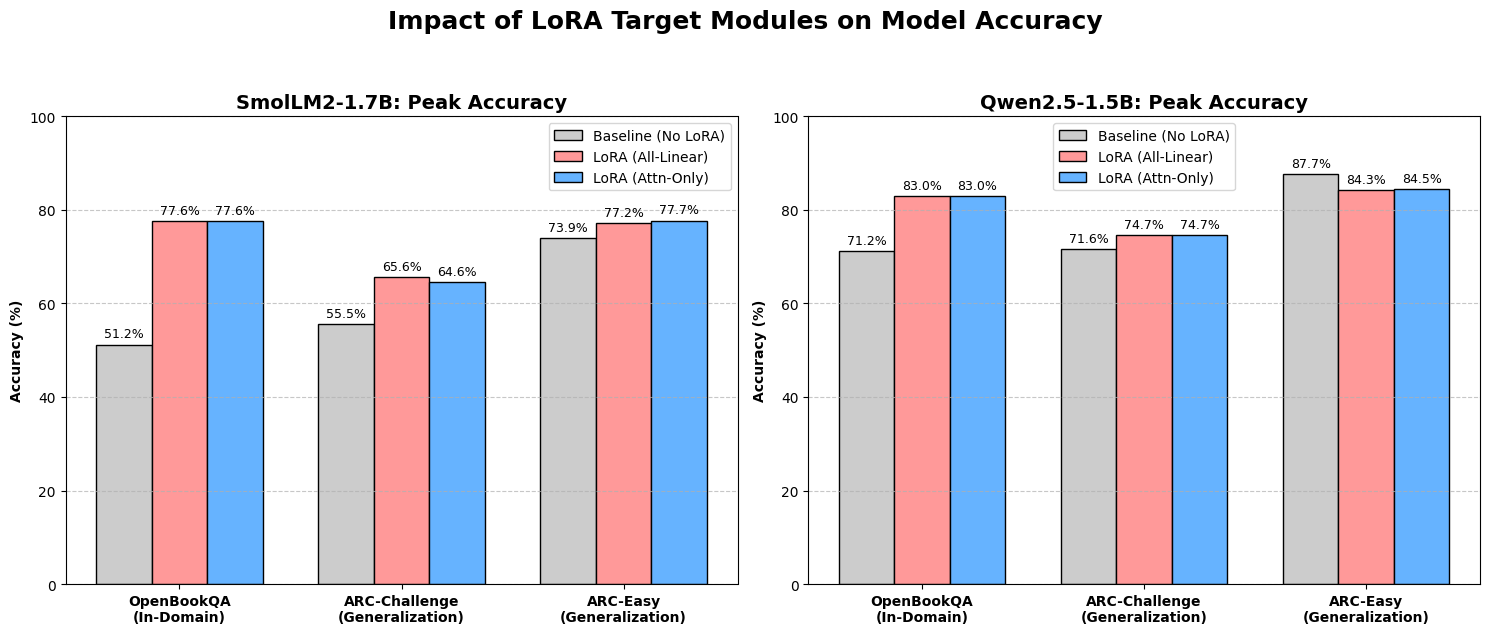

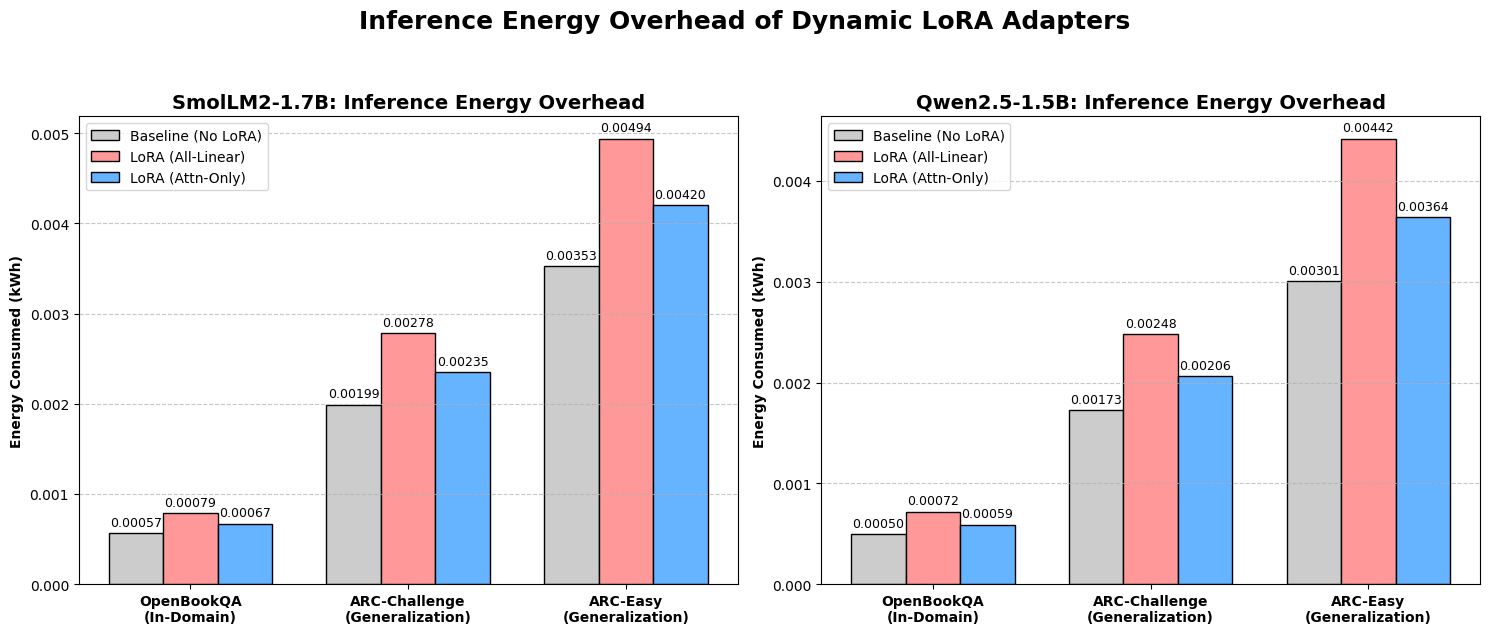

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. THE AGGREGATED DATA
# ==========================================

datasets = ['OpenBookQA\n(In-Domain)', 'ARC-Challenge\n(Generalization)', 'ARC-Easy\n(Generalization)']
x = np.arange(len(datasets))
width = 0.25  # Width of the bars

# Peak Accuracy Data (%)
acc_smol = {
    'Baseline': [51.2, 55.5, 73.9],
    'All-Linear': [77.6, 65.6, 77.2],
    'Attn-Only (qkvo)': [77.6, 64.6, 77.7]
}
acc_qwen = {
    'Baseline': [71.2, 71.6, 87.7],
    'All-Linear': [83.0, 74.7, 84.3], # Note: Drop in ARC-Easy is expected Catastrophic Forgetting
    'Attn-Only (qkvo)': [83.0, 74.7, 84.5]
}

# Average Inference Energy (kWh per run)
energy_smol = {
    'Baseline': [0.00057, 0.00199, 0.00353],
    'All-Linear': [0.00079, 0.00278, 0.00494],
    'Attn-Only (qkvo)': [0.00067, 0.00235, 0.00420]
}
energy_qwen = {
    'Baseline': [0.00050, 0.00173, 0.00301],
    'All-Linear': [0.00072, 0.00248, 0.00442],
    'Attn-Only (qkvo)': [0.00059, 0.00206, 0.00364]
}

# Colors for the bars
colors = ['#cccccc', '#ff9999', '#66b3ff'] # Gray for Baseline, Red for All-Linear, Blue for Attn-Only

# ==========================================
# 2. PLOTTING FUNCTION
# ==========================================

def plot_grouped_bars(ax, data_dict, title, ylabel, is_percentage=False):
    """Utility function to plot grouped bar charts."""
    # Plot bars
    bars1 = ax.bar(x - width, data_dict['Baseline'], width, label='Baseline (No LoRA)', color=colors[0], edgecolor='black')
    bars2 = ax.bar(x, data_dict['All-Linear'], width, label='LoRA (All-Linear)', color=colors[1], edgecolor='black')
    bars3 = ax.bar(x + width, data_dict['Attn-Only (qkvo)'], width, label='LoRA (Attn-Only)', color=colors[2], edgecolor='black')

    # Formatting
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add text labels on top of the bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            label_text = f"{height:.1f}%" if is_percentage else f"{height:.5f}"
            ax.annotate(label_text,
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

# ==========================================
# 3. GENERATE FIGURE 1: ACCURACY
# ==========================================
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_grouped_bars(ax1, acc_smol, 'SmolLM2-1.7B: Peak Accuracy', 'Accuracy (%)', is_percentage=True)
plot_grouped_bars(ax2, acc_qwen, 'Qwen2.5-1.5B: Peak Accuracy', 'Accuracy (%)', is_percentage=True)

# Set Y-axis limit identically for fair visual comparison
ax1.set_ylim(0, 100)
ax2.set_ylim(0, 100)
fig1.suptitle("Impact of LoRA Target Modules on Model Accuracy", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=300, bbox_inches='tight')
print("✅ Saved 'accuracy_comparison.png'")

# ==========================================
# 4. GENERATE FIGURE 2: INFERENCE ENERGY
# ==========================================
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))
plot_grouped_bars(ax3, energy_smol, 'SmolLM2-1.7B: Inference Energy Overhead', 'Energy Consumed (kWh)', is_percentage=False)
plot_grouped_bars(ax4, energy_qwen, 'Qwen2.5-1.5B: Inference Energy Overhead', 'Energy Consumed (kWh)', is_percentage=False)

fig2.suptitle("Inference Energy Overhead of Dynamic LoRA Adapters", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig("inference_energy_comparison.png", dpi=300, bbox_inches='tight')
print("✅ Saved 'inference_energy_comparison.png'")

plt.show()

In [5]:
import json
import math

def print_metrics(json_file_path, a=1.0):
    # 1. Load the JSON data
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    print(f"--- Metrics for: {json_file_path} ---\n")
    
    # 2. Iterate through each run and calculate the new metrics
    for run in data:
        description = run.get('description', 'No description found')
        
        # Base values
        accuracy = run.get('parser_acc', 0.0)
        time_s = run.get('duration_seconds', 0.0)
        
        # Calculate Power (W)
        cpu_p = run.get('cpu_power_watts', 0.0)
        gpu_p = run.get('gpu_power_watts', 0.0)
        ram_p = run.get('ram_power_watts', 0.0)
        power_w = cpu_p + gpu_p + ram_p
        
        # Calculate Energy (Joules)
        energy_j = power_w * time_s
        
        # Calculate Watt-hours (Wh) for SAM
        time_h = time_s / 3600.0
        wh = power_w * time_h
        
        # Calculate SAM = (score^a) / log10(Wh)
        # Adding a safeguard just in case Wh is exactly 1.0 (which would cause division by zero)
        if wh > 0 and wh != 1.0:
            sam = (accuracy ** a) / math.log10(wh)
        else:
            sam = 0.0
            
        # 3. Print the formatted result (all with 2 decimal precision)
        print(f"Description: {description}")
        print(f"Accuracy:    {accuracy:.2f}")
        print(f"Time:        {time_s:.2f} s")
        print(f"Power:       {power_w:.2f} W")
        print(f"Energy:      {energy_j:.2f} Joules")
        print(f"SAM (a={a}):  {sam:.2f}")
        print("-" * 40)

# Simply pass your JSON filename here. You can also change the 'a' parameter!

print_metrics("results/arc_challenge_qwen_attn.json", a=1.0)

--- Metrics for: results/arc_challenge_qwen_attn.json ---

Description: Inference of the Qwen/Qwen2.5-1.5B-Instruct on arc_challenge_qwen_attn dataset!
Accuracy:    0.72
Time:        112.93 s
Power:       73.34 W
Energy:      8282.15 Joules
SAM (a=1.0):  1.98
----------------------------------------
Description: Inference of the Qwen/Qwen2.5-1.5B-Instruct on arc_challenge_qwen_attn dataset!
Accuracy:    0.74
Time:        113.47 s
Power:       73.54 W
Energy:      8344.54 Joules
SAM (a=1.0):  2.04
----------------------------------------
Description: Inference of the Qwen/Qwen2.5-1.5B-Instruct on arc_challenge_qwen_attn dataset!
Accuracy:    0.74
Time:        112.37 s
Power:       73.46 W
Energy:      8254.40 Joules
SAM (a=1.0):  2.04
----------------------------------------
Description: Inference of the Qwen/Qwen2.5-1.5B-Instruct on arc_challenge_qwen_attn dataset!
Accuracy:    0.75
Time:        112.36 s
Power:       73.40 W
Energy:      8247.06 Joules
SAM (a=1.0):  2.07
--------------

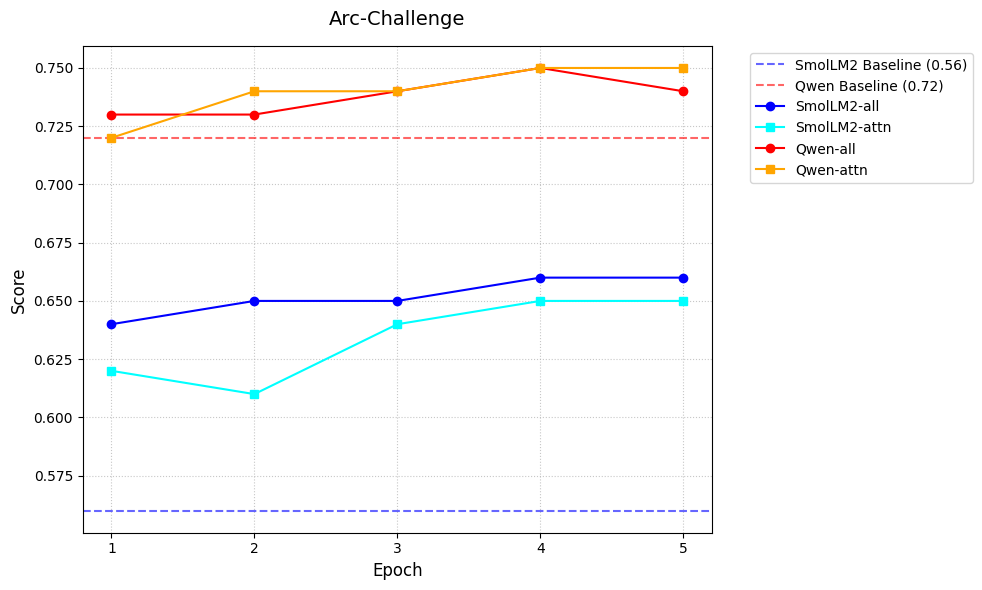

In [20]:
import matplotlib.pyplot as plt

# 1. Define the Data
epochs = [1, 2, 3, 4, 5]

smollm2_all = [  0.64,
0.65,
0.65,
0.66,
0.66,
]
smollm2_attn = [
0.62,
0.61,
0.64,
0.65,
0.65,
]

qwen_all = [  0.73,
0.73,
0.74,
0.75,
0.74,
]
qwen_attn = [  0.72,
0.74,
0.74,
0.75,
0.75,
]

baseline_smollm2 = 0.56
baseline_qwen = 0.72

# 2. Initialize the Plot
plt.figure(figsize=(10, 6))

# 3. Plot Baselines
# Using axhline to create a horizontal line across all epochs
plt.axhline(y=baseline_smollm2, color='blue', linestyle='--', alpha=0.6, label=f'SmolLM2 Baseline ({baseline_smollm2})')
plt.axhline(y=baseline_qwen, color='red', linestyle='--', alpha=0.6, label=f'Qwen Baseline ({baseline_qwen})')

# 4. Plot the Epoch Lines
plt.plot(epochs, smollm2_all, marker='o', color='blue', label='SmolLM2-all')
plt.plot(epochs, smollm2_attn, marker='s', color='cyan', label='SmolLM2-attn')

plt.plot(epochs, qwen_all, marker='o', color='red', label='Qwen-all')
plt.plot(epochs, qwen_attn, marker='s', color='orange', label='Qwen-attn')

# 5. Formatting and Aesthetics
plt.title('Arc-Challenge', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(epochs) # Ensures only whole numbers (1-5) show on the x-axis
plt.grid(True, linestyle=':', alpha=0.7)

# Place the legend outside the plot area if it overlaps with the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Display the Graph
plt.tight_layout() # Adjusts layout so the legend doesn't get cut off
plt.show()

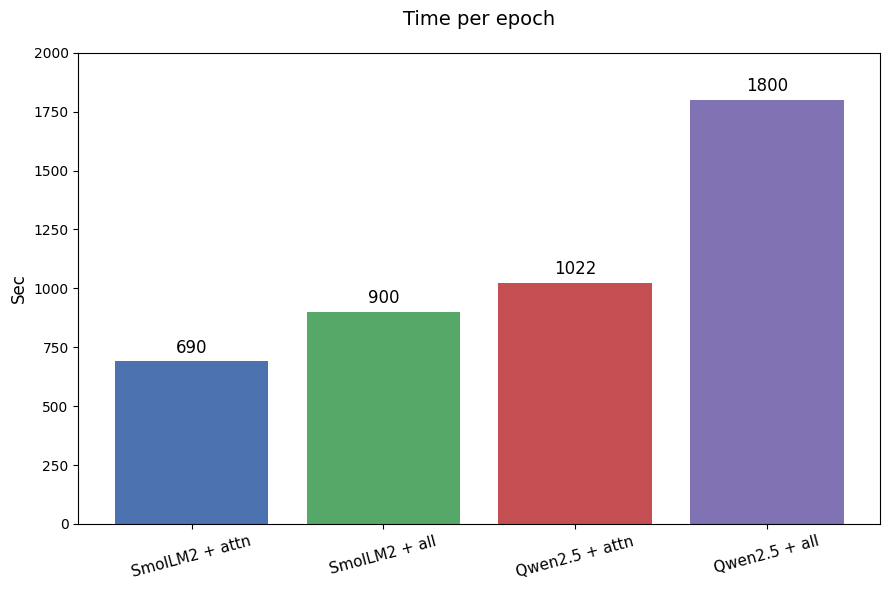

In [13]:
import matplotlib.pyplot as plt

# Define the data
categories = ['SmolLM2 + all', 'Qwen2.5 + all', 'SmolLM2 + attn', 'Qwen2.5 + attn']
values = [900, 1800, 690, 1022]

# Sort the data in ascending order based on values
sorted_data = sorted(zip(categories, values), key=lambda x: x[1])
sorted_categories = [x[0] for x in sorted_data]
sorted_values = [x[1] for x in sorted_data]

# Initialize the plot
plt.figure(figsize=(9, 6))

# Create the bar plot
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']
bars = plt.bar(sorted_categories, sorted_values, color=colors)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0, 
        height + 20, # Offset slightly above the bar
        f'{int(height)}', 
        ha='center', 
        va='bottom', 
        fontsize=12
    )

# Formatting and aesthetics
plt.title('Time per epoch', fontsize=14, pad=20)
plt.ylabel('Sec', fontsize=12)
plt.xticks(rotation=15, fontsize=11) # Rotate slightly to prevent overlapping text
plt.ylim(0, max(sorted_values) + 200) # Give some headroom for the text labels

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig('bar_plot.png')